# HuggingFace Project

This project:
- Generates text from a user title
- Summarizes the text
- Generates an image related to the title
- Describes the generated image

In [ ]:
!pip uninstall -y transformers
!pip install transformers==4.52.3 sentencepiece accelerate

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 80.4 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.6.0
    Uninstalling huggingface_hub-1.6.0:
      Successfully uninstalled huggingface_hub-1.6.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2


## Text Generation & Text Summarization

In [ ]:
from transformers import pipeline

generator = pipeline("text-generation", model="gpt2")
summarizer = pipeline("summarization")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


In [ ]:
def generate(prompt):
    result = generator(prompt, max_new_tokens=100, truncation=True)
    text = result[0]["generated_text"]
    return text

In [ ]:
def summarize(paragraph):
    result = summarizer(paragraph)
    summary = result[0]["summary_text"]
    return summary

In [ ]:
title = input("Enter a title: ")

prompt = f"Write a short informative paragraph about {title}"

paragraph = generate(prompt)

summary = summarize(paragraph)

print("\nGenerated Paragraph:")
print(paragraph)

print("\nSummary:")
print(summary)

Enter a title: healthy life


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Your max_length is set to 142, but your input_length is only 110. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=55)



Generated Paragraph:
Write a short informative paragraph about healthy life, a story about health, or a brief analysis of health care.

2. Use the word "disease." If you're going to talk about a disease, you should use the word "disease."

3. Use health care as a way to express compassion for a disease.

4. The word "disease" is not used as a way to describe how sick a person is.

5. The word "disease" is

Summary:
 The word "disease" is not used as a way to describe how sick a person is . Write a short informative paragraph about healthy life, a story about health care, or a brief analysis of health care . Use health care as way to express compassion for a disease .


In [ ]:
!pip install diffusers
!pip install torch
!pip install transformers accelerate

## Image Generation
Generate an image related to the input title using Stable Diffusion.

In [ ]:
from diffusers import StableDiffusionPipeline
import torch

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5"
)

pipe = pipe.to("cpu")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [ ]:
def generate_image(prompt):

    image = pipe(prompt).images[0]

    return image

  0%|          | 0/50 [00:00<?, ?it/s]

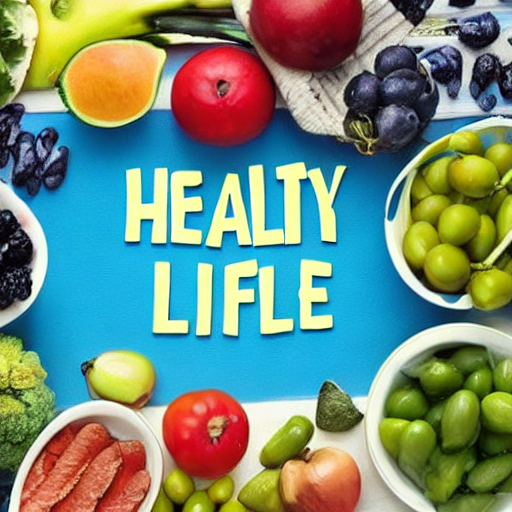

In [ ]:
image = generate_image(title)

image

## Image Description
Describe the generated image using an image captioning model.

In [ ]:
image_describer = pipeline("image-to-text", model="Salesforce/blip-image-captioning-base")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cpu


In [ ]:
def describe_image(image):
    result = image_describer(image)
    description = result[0]["generated_text"]
    return description

In [ ]:
description = describe_image(image)

print("\nImage Description:")
print(description)


Image Description:
a table with bowls of fruit and vegetables
